## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score)

In [ ]:
                             classification_report, precision_score,
                             recall_score, f1_score)

## 2. Load Data

In [33]:
df = pd.read_csv('/content/train_sample.csv')
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


## 3. Explore Data

In [34]:
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

Shape: (100000, 24)

Column types:
id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id              object
site_domain          object
site_category        object
app_id               object
app_domain           object
app_category         object
device_id            object
device_ip            object
device_model         object
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
dtype: object


## 4. Check Missing Values

In [35]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64


### 4.1 Impute Missing Values

In [36]:
# Impute missing numerical values with the mean
numeric_cols_with_nan = [
    'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'
]
for col in numeric_cols_with_nan:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

print('Missing values after imputation:')
print(df[numeric_cols_with_nan].isnull().sum())


Missing values after imputation:
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64


## 5. Check & Remove Duplicates

In [37]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


## 6. Drop ID Column

In [38]:
df = df.drop(columns=['id'])
display(df.head())

,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1,2,15706,320,50,1722,0,35,-1,79
1,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1,0,15704,320,50,1722,0,35,100084,79
2,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1,0,15704,320,50,1722,0,35,100084,79
3,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1,0,15706,320,50,1722,0,35,100084,79
4,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,...,1,0,18993,320,50,2161,0,35,-1,157


## 7. Click Distribution

Click distribution:
click
0    82510
1    17490
Name: count, dtype: int64


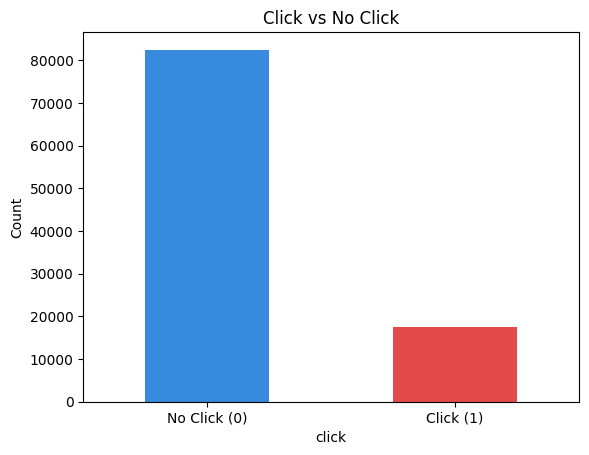

In [39]:
print('Click distribution:')
print(df['click'].value_counts())
df['click'].value_counts().plot(kind='bar', color=['#378ADD','#E24B4A'])
plt.title('Click vs No Click')
plt.xticks([0,1], ['No Click (0)', 'Click (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

## 8. Exploratory Data Analysis (EDA)

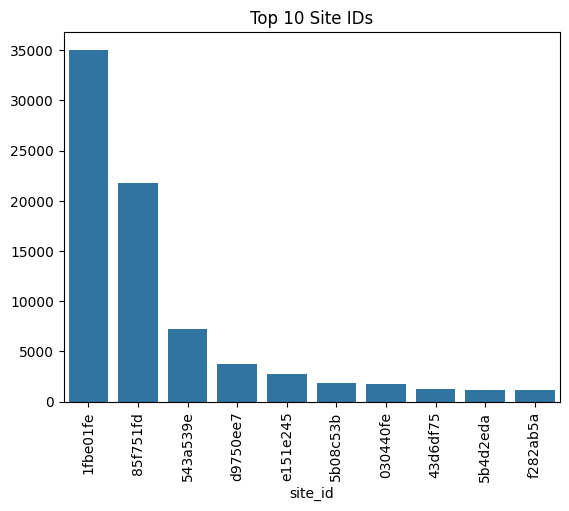

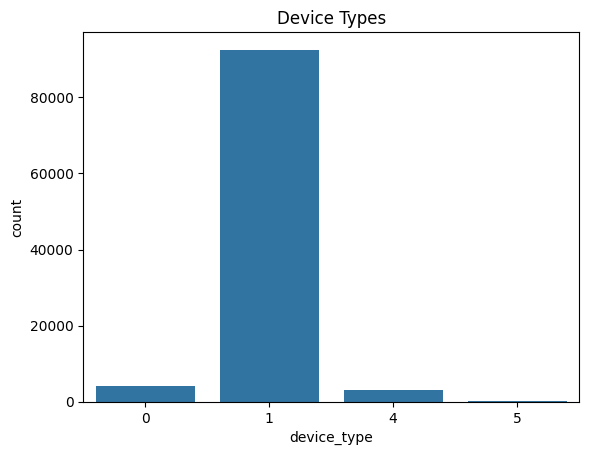

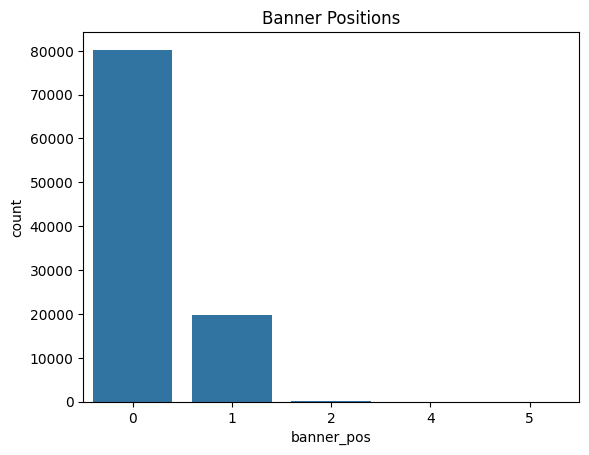

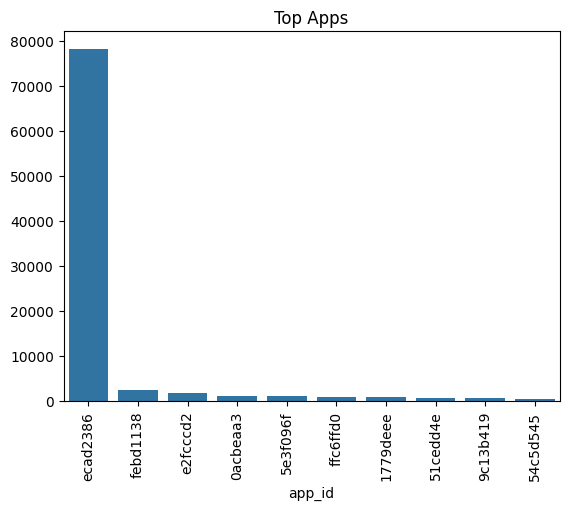

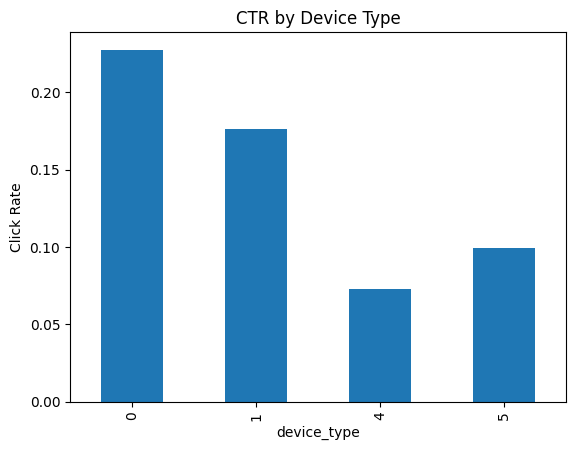

In [40]:
top_sites = df['site_id'].value_counts().head(10)
sns.barplot(x=top_sites.index, y=top_sites.values)
plt.xticks(rotation=90)
plt.title('Top 10 Site IDs')
plt.show()

sns.countplot(x='device_type', data=df)
plt.title('Device Types')
plt.show()

sns.countplot(x='banner_pos', data=df)
plt.title('Banner Positions')
plt.show()

top_apps = df['app_id'].value_counts().head(10)
sns.barplot(x=top_apps.index, y=top_apps.values)
plt.xticks(rotation=90)
plt.title('Top Apps')
plt.show()

device_click = df.groupby('device_type')['click'].mean()
device_click.plot(kind='bar')
plt.title('CTR by Device Type')
plt.ylabel('Click Rate')
plt.show()

## 9. Outliers Detection

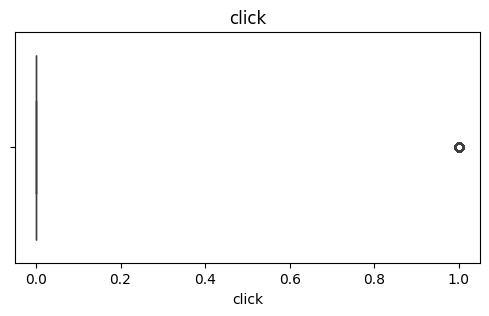

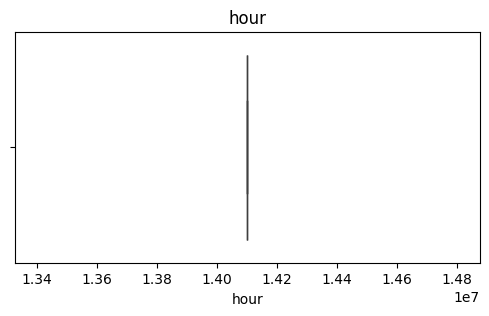

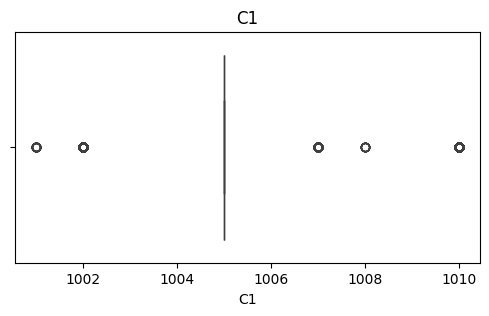

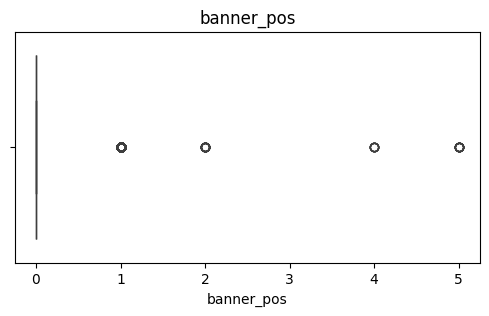

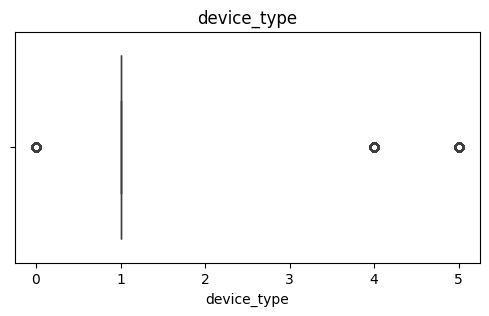

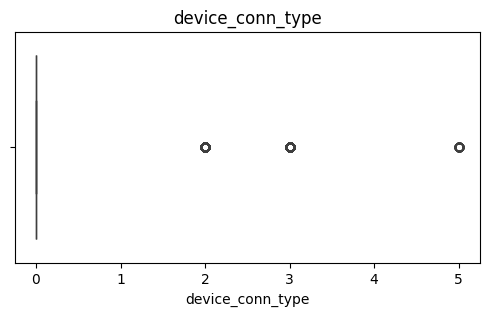

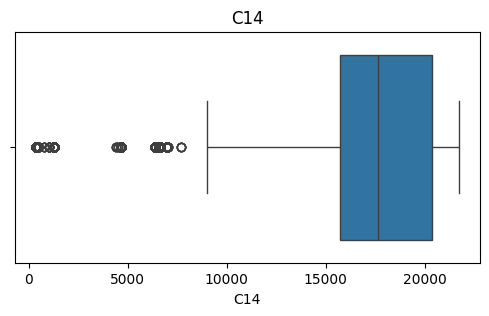

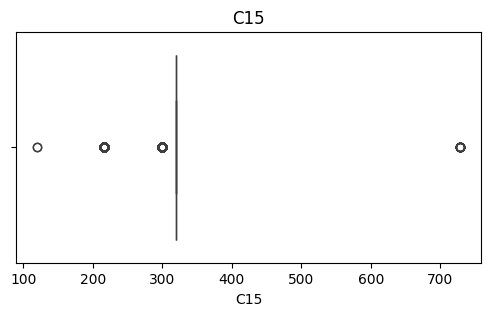

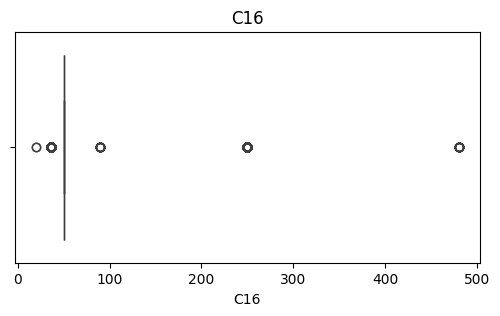

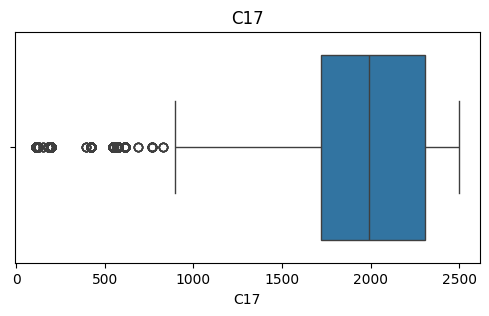

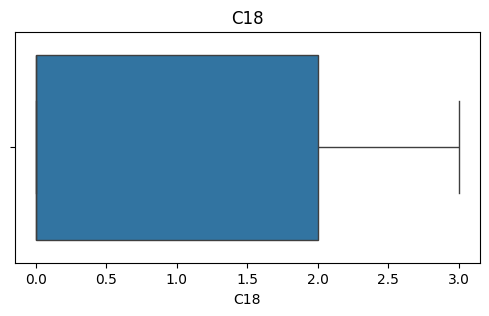

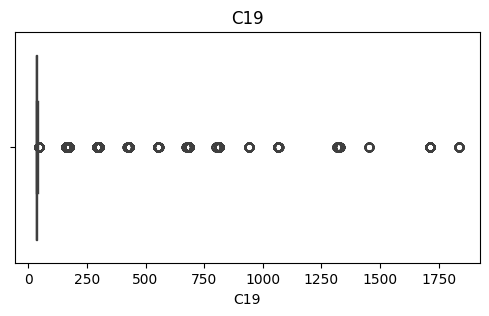

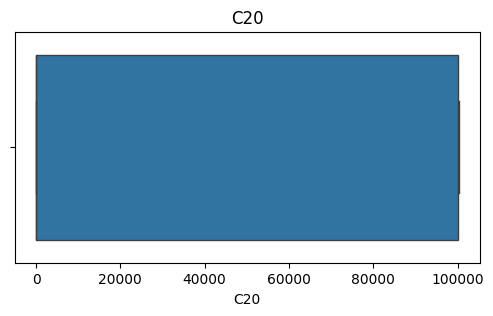

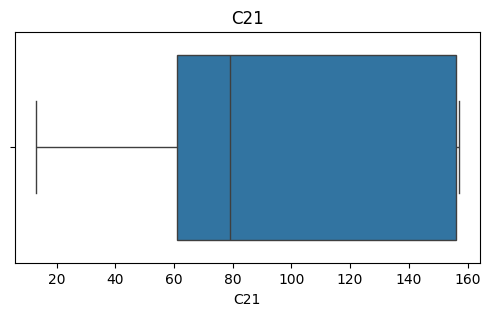

In [41]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## 10. Feature Engineering — Extract Time Features

In [42]:
df['hour'] = pd.to_datetime(df['hour'], format='%y%m%d%H')
df['day'] = df['hour'].dt.day
df['day_of_week'] = df['hour'].dt.dayofweek
df['hour_of_day'] = df['hour'].dt.hour
df = df.drop('hour', axis=1)
display(df.head())

,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,...,C15,C16,C17,C18,C19,C20,C21,day,day_of_week,hour_of_day
0,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,320,50,1722,0,35,-1,79,21,1,0
1,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,320,50,1722,0,35,100084,79,21,1,0
2,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,320,50,1722,0,35,100084,79,21,1,0
3,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,320,50,1722,0,35,100084,79,21,1,0
4,0,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,...,320,50,2161,0,35,-1,157,21,1,0


## 11. Train / Test Split

In [43]:
X = df.drop('click', axis=1)
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (80000, 24)
Test size:  (20000, 24)


## 12. Target Encoding (High Cardinality Columns)

In [44]:
high_card_cols = ['site_id','site_domain','app_id','app_domain',
                  'device_id','device_ip','device_model']

for col in high_card_cols:
    ctr = X_train.join(y_train).groupby(col)['click'].mean()
    X_train[col + '_ctr'] = X_train[col].map(ctr)
    X_test[col + '_ctr'] = X_test[col].map(ctr).fillna(y_train.mean())
    X_train.drop(col, axis=1, inplace=True)
    X_test.drop(col, axis=1, inplace=True)

print('Shapes after Target Encoding:', X_train.shape, X_test.shape)

Shapes after Target Encoding: (80000, 24) (20000, 24)


## 13. Label Encoding (Remaining Categorical Columns)

In [45]:
cat_cols = X_train.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(
        dict(zip(le.classes_, le.transform(le.classes_)))
    ).fillna(-1).astype(int)

print(X_train.dtypes)
print('Shape after Label Encoding:', X_train.shape)

C1                    int64
banner_pos            int64
site_category         int64
app_category          int64
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
day                   int32
day_of_week           int32
hour_of_day           int32
site_id_ctr         float64
site_domain_ctr     float64
app_id_ctr          float64
app_domain_ctr      float64
device_id_ctr       float64
device_ip_ctr       float64
device_model_ctr    float64
dtype: object
Shape after Label Encoding: (80000, 24)


## 14. Feature Selection — SelectKBest (Filter Method)

In [46]:
from sklearn.feature_selection import SelectKBest, f_classif
#Filter Method Used: ANOVA (F-Test)
selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_mask = selector.get_support()
selected_cols = X_train.columns[selected_mask].tolist()
print('Features Kept:', selected_cols)
print('Features before:', X_train.shape[1], '→ after:', X_train_selected.shape[1])

Features Kept: ['C1', 'app_category', 'device_type', 'C14', 'C16', 'C17', 'C19', 'C21', 'site_id_ctr', 'site_domain_ctr', 'app_id_ctr', 'app_domain_ctr', 'device_id_ctr', 'device_ip_ctr', 'device_model_ctr']
Features before: 24 → after: 15


## 15. Feature Scaling — StandardScaler

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print('Scaled shapes:', X_train_scaled.shape, X_test_scaled.shape)
print('Original class distribution:', Counter(y_train))

Scaled shapes: (80000, 15) (20000, 15)
Original class distribution: Counter({0: 66008, 1: 13992})


## 16. Handle Class Imbalance — SMOTE

After SMOTE: Counter({1: 66008, 0: 66008})


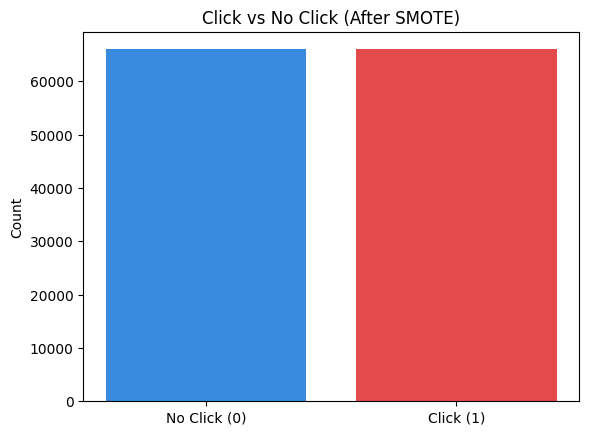

In [48]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE:', Counter(y_train_resampled))

dist = Counter(y_train_resampled)
plt.bar(['No Click (0)', 'Click (1)'], [dist[0], dist[1]], color=['#378ADD','#E24B4A'])
plt.title('Click vs No Click (After SMOTE)')
plt.ylabel('Count')
plt.show()

## 17. Confirm Shapes Before Training

In [49]:
print('X_train_resampled shape:', X_train_resampled.shape)
print('X_test_scaled shape:     ', X_test_scaled.shape)
print('y_train_resampled shape: ', y_train_resampled.shape)

X_train_resampled shape: (132016, 15)
X_test_scaled shape:      (20000, 15)
y_train_resampled shape:  (132016,)


## 18. Model 1 — Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred = lr_model.predict(X_test_scaled)
print('=== Logistic Regression ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.7866
Confusion Matrix:
 [[14436  2066]
 [ 2202  1296]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87     16502
           1       0.39      0.37      0.38      3498

    accuracy                           0.79     20000
   macro avg       0.63      0.62      0.62     20000
weighted avg       0.78      0.79      0.78     20000



## 19. Model 2 — K-Nearest Neighbors (KNN)

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_resampled, y_train_resampled)

y_pred = knn_model.predict(X_test_scaled)
print('=== KNN ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== KNN ===
Accuracy: 0.7389
Confusion Matrix:
 [[13244  3258]
 [ 1964  1534]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.84     16502
           1       0.32      0.44      0.37      3498

    accuracy                           0.74     20000
   macro avg       0.60      0.62      0.60     20000
weighted avg       0.77      0.74      0.75     20000



## 20. Model 3 — Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred = rf_model.predict(X_test_scaled)
print('=== Random Forest ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== Random Forest ===
Accuracy: 0.76515
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86     16502
           1       0.35      0.40      0.37      3498

    accuracy                           0.77     20000
   macro avg       0.61      0.62      0.61     20000
weighted avg       0.78      0.77      0.77     20000



## 21. Model 4 — Gradient Boosting

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

y_pred = gb_model.predict(X_test_scaled)
print('=== Gradient Boosting ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== Gradient Boosting ===
Accuracy: 0.7602
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85     16502
           1       0.36      0.47      0.41      3498

    accuracy                           0.76     20000
   macro avg       0.62      0.65      0.63     20000
weighted avg       0.79      0.76      0.77     20000



## 22. Model 5 — XGBoost

In [54]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred = xgb_model.predict(X_test_scaled)
print('=== XGBoost ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== XGBoost ===
Accuracy: 0.73155
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.78      0.83     16502
           1       0.32      0.49      0.39      3498

    accuracy                           0.73     20000
   macro avg       0.60      0.64      0.61     20000
weighted avg       0.78      0.73      0.75     20000



## 23. Model 6 — LightGBM

In [55]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=200, learning_rate=0.05,
                            random_state=42, verbose=-1)
lgbm_model.fit(X_train_resampled, y_train_resampled)

y_pred = lgbm_model.predict(X_test_scaled)
print('=== LightGBM ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== LightGBM ===
Accuracy: 0.7207
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82     16502
           1       0.31      0.48      0.38      3498

    accuracy                           0.72     20000
   macro avg       0.59      0.63      0.60     20000
weighted avg       0.78      0.72      0.74     20000



## 24. Model 7 — CatBoost

In [56]:
!pip install catboost -q
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=200, learning_rate=0.05,
                               random_state=42, verbose=0)
cat_model.fit(X_train_resampled, y_train_resampled)

y_pred = cat_model.predict(X_test_scaled)
print('=== CatBoost ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

=== CatBoost ===
Accuracy: 0.7593
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85     16502
           1       0.35      0.45      0.39      3498

    accuracy                           0.76     20000
   macro avg       0.61      0.64      0.62     20000
weighted avg       0.78      0.76      0.77     20000



## 25. Model Comparison

In [57]:
models = {
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'CatBoost': cat_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print('Model Comparison Results:')
display(results_df)

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.78660,0.385485,0.370497,0.377843
1,KNN,0.73890,0.320117,0.438536,0.370084
2,Random Forest,0.76515,0.349862,0.399371,0.372981
3,Gradient Boosting,0.76020,0.359341,0.473985,0.408777
4,XGBoost,0.73155,0.322856,0.487421,0.388427
5,LightGBM,0.72070,0.309141,0.483419,0.377119
6,CatBoost,0.75930,0.352002,0.447399,0.394008


## 26. Model Comparison Chart

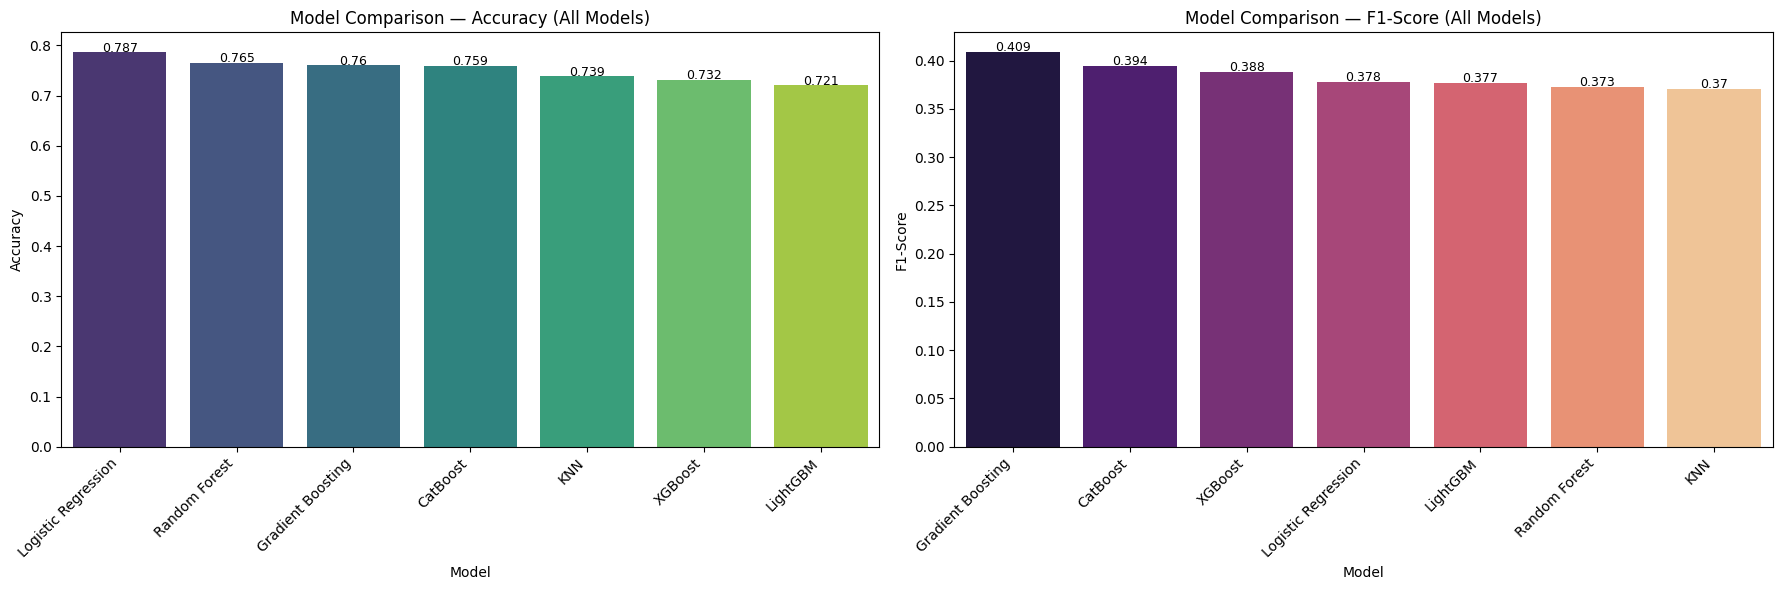

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(ax=axes[0], x='Model', y='Accuracy',
            data=results_df.sort_values(by='Accuracy', ascending=False), palette='viridis', hue='Model', legend=False)
axes[0].set_title('Model Comparison — Accuracy (All Models)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
for i, row in results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True).iterrows():
    axes[0].text(i, row.Accuracy + 0.001, str(round(row.Accuracy, 3)), ha='center', fontsize=9)

sns.barplot(ax=axes[1], x='Model', y='F1-Score',
            data=results_df.sort_values(by='F1-Score', ascending=False), palette='magma', hue='Model', legend=False)
axes[1].set_title('Model Comparison — F1-Score (All Models)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, row in results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True).iterrows():
    axes[1].text(i, row['F1-Score'] + 0.001, str(round(row['F1-Score'], 3)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 27. Soft Voting Ensemble — Best Model

In [59]:
from sklearn.ensemble import VotingClassifier

# Soft Voting using the 3 best models by F1-Score
# GB: 0.4088 | CatBoost: 0.3940 | XGBoost: 0.3884
voting_model = VotingClassifier(
    estimators=[
        ('gb',  gb_model),
        ('cat', cat_model),
        ('xgb', xgb_model),
    ],
    voting='soft'
)

voting_model.fit(X_train_resampled, y_train_resampled)
y_pred_voting = voting_model.predict(X_test_scaled)

print('=== Soft Voting Ensemble (GB + CatBoost + XGBoost) ===')
print('Accuracy:  ', round(accuracy_score(y_test, y_pred_voting), 4))
print('Precision: ', round(precision_score(y_test, y_pred_voting), 4))
print('Recall:    ', round(recall_score(y_test, y_pred_voting), 4))
print('F1-Score:  ', round(f1_score(y_test, y_pred_voting), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_voting))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_voting))


## 28. Save Voting Model for Deployment

In [60]:
import pickle
from google.colab import files

with open('voting_model.pkl', 'wb') as f:
    pickle.dump(voting_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('selector.pkl', 'wb') as f:
    pickle.dump(selector, f)

files.download('voting_model.pkl')
files.download('scaler.pkl')
files.download('selector.pkl')

print('Files saved and downloaded!')
